In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
data = pd.read_csv("exoplanet_data.csv", comment = "#")
df = pd.DataFrame(data)
df

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,7 CMa c,7 CMa,0,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2024-09-13,2024-07,2024-09-13
1,7 CMa c,7 CMa,1,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2019-10-18,2019-11,2019-10-24
2,DMPP-1 b,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2020-01-23,2019-12,2020-01-30
3,DMPP-1 c,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2020-01-23,2019-12,2020-01-30
4,DMPP-1 d,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2020-01-23,2019-12,2020-01-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
565,bet Pic c,bet Pic,0,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2025-09-25,2020-10,2025-09-25
566,bet Pic c,bet Pic,1,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2023-06-12,2022-09,2023-06-12
567,bet Pic c,bet Pic,0,1,2,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,3.526,0.222,-0.222,3.82015,0.004427,-0.004427,2019-08-23,2019-08,2019-08-29
568,eps Ind A b,eps Ind A,1,3,1,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,2.237,0.240,-0.240,4.34562,0.007374,-0.007374,2024-08-07,2024-09,2024-08-07


In [3]:
df.shape # 570 x 92
# 570 rows, 92 columns

(570, 92)

In [4]:
list(df.columns)
# pl_orbper, pl_orbsmax, pl_radeerr1, pl_rade, sy_gaiamag

['pl_name',
 'hostname',
 'default_flag',
 'sy_snum',
 'sy_pnum',
 'discoverymethod',
 'disc_year',
 'disc_facility',
 'soltype',
 'pl_controv_flag',
 'pl_refname',
 'pl_orbper',
 'pl_orbpererr1',
 'pl_orbpererr2',
 'pl_orbperlim',
 'pl_orbsmax',
 'pl_orbsmaxerr1',
 'pl_orbsmaxerr2',
 'pl_orbsmaxlim',
 'pl_rade',
 'pl_radeerr1',
 'pl_radeerr2',
 'pl_radelim',
 'pl_radj',
 'pl_radjerr1',
 'pl_radjerr2',
 'pl_radjlim',
 'pl_bmasse',
 'pl_bmasseerr1',
 'pl_bmasseerr2',
 'pl_bmasselim',
 'pl_bmassj',
 'pl_bmassjerr1',
 'pl_bmassjerr2',
 'pl_bmassjlim',
 'pl_bmassprov',
 'pl_orbeccen',
 'pl_orbeccenerr1',
 'pl_orbeccenerr2',
 'pl_orbeccenlim',
 'pl_insol',
 'pl_insolerr1',
 'pl_insolerr2',
 'pl_insollim',
 'pl_eqt',
 'pl_eqterr1',
 'pl_eqterr2',
 'pl_eqtlim',
 'ttv_flag',
 'st_refname',
 'st_spectype',
 'st_teff',
 'st_tefferr1',
 'st_tefferr2',
 'st_tefflim',
 'st_rad',
 'st_raderr1',
 'st_raderr2',
 'st_radlim',
 'st_mass',
 'st_masserr1',
 'st_masserr2',
 'st_masslim',
 'st_met',
 'st_me

In [5]:
# Planet Name, pl_name, Planet name most commonly used in the literature, the planet's name that is used the most in research papers and articles
# Host name, hostname, Stellar name most commonly used in the literature, the name of the star that is used the most in research papers and articles
# Discovery Method, discoverymethod, Method by which the planet was first identified, method was used to discover the exoplanet (ex. radial velocity)
# spectral type, st_spectype, Classification of the star based on their spectral characteristics following the Morgan-Keenan system, type of star based on surface temperature (OBAFGKM)
# equilibrium temperature [K], pl_eqt, The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body, describes the planet's temperature if the amount of energy from its star balances the amount of energy it radiates back into space as a black body
# Planet Mass or Mass*sin(i) [Earth Mass], pl_bmassj, Minimum mass of a planet as measured by radial velocity, measured in units of masses of Jupiter, the mass of the planet in jupiter masses through the radial velocity (minimum mass unless the system is edge on)

In [14]:
new_df = df[["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]]
print(new_df)

         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
0        7 CMa c      7 CMa  Radial Velocity         NaN     NaN   0.912000
1        7 CMa c      7 CMa  Radial Velocity         NaN     NaN   0.870000
2       DMPP-1 b     DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3       DMPP-1 c     DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4       DMPP-1 d     DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
..           ...        ...              ...         ...     ...        ...
565    bet Pic c    bet Pic  Radial Velocity         NaN  1250.0   8.200000
566    bet Pic c    bet Pic  Radial Velocity         NaN     NaN  10.139000
567    bet Pic c    bet Pic  Radial Velocity         NaN     NaN   9.000000
568  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0   6.310000
569  eps Ind A b  eps Ind A  Radial Velocity        K2 V     NaN   3.250000

[570 rows x 6 columns]


In [84]:
new2_df = new_df.dropna()
new2_df

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
5,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
6,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000
...,...,...,...,...,...,...
549,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980000
554,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000000
557,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300000
562,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709000


In [88]:
new2_df.shape # 67, 6
# 67 rows, 6 columns

(67, 6)

In [86]:
new2_df.head()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
5,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
6,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000


In [87]:
new2_df.tail()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
549,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980
554,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000
557,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300
562,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709
568,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.310


In [89]:
list(new2_df.columns)

['pl_name',
 'hostname',
 'discoverymethod',
 'st_spectype',
 'pl_eqt',
 'pl_bmassj']

In [92]:
new2_df.value_counts("discoverymethod")
# transit, radial velocity, imaging
# 52, 13, 2, transit has the most, imaging has the least
# transit works by observing the star when the planet passes in front of it in our line of sight. when this happens, the star's light dims a little which we can detect
# radial velocity measures the impact of the planet's gravitational force on the star. The planet's gravity causes the star to move in small circles and we can observe whether the star's light is red shifted (moving away from us) or blue shifted (moving closer to us). We can determine characteristics of the planet by analzying the shifts.
# imaging works by simply capturing images of planets using a coronagraph to block the light of the host star(s)

discoverymethod
Transit            52
Radial Velocity    13
Imaging             2
Name: count, dtype: int64

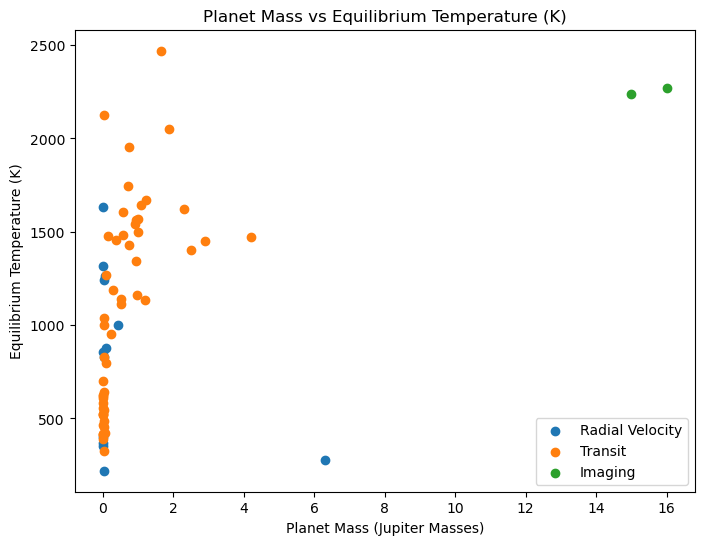

In [93]:
plt.figure(figsize = (8, 6)) 
discovery_method = new2_df["discoverymethod"].unique()
for method in discovery_method:
    mask = new2_df["discoverymethod"] == method
    plt.scatter(new2_df.loc[mask, "pl_bmassj"], new2_df.loc[mask, "pl_eqt"], label = method)
plt.title("Planet Mass vs Equilibrium Temperature (K)")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend()
plt.show()

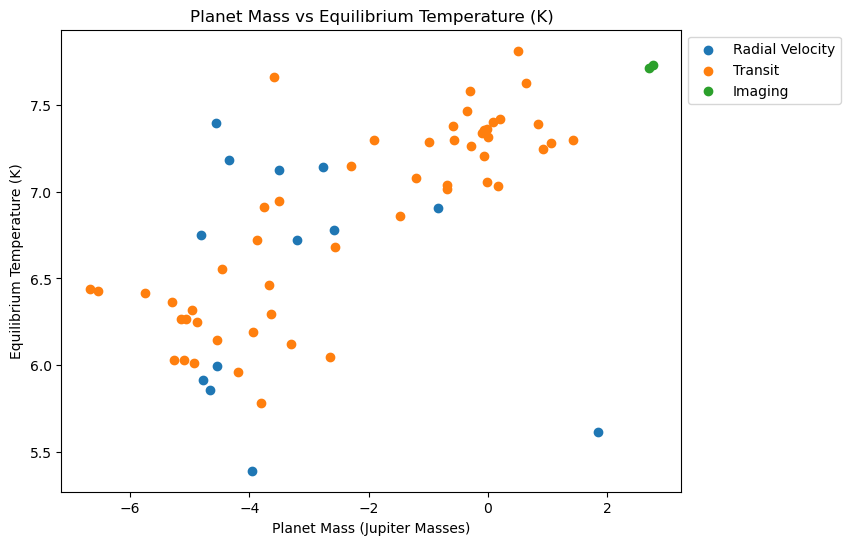

In [102]:
plt.figure(figsize = (8, 6)) 
discovery_method = new2_df["discoverymethod"].unique()
for method in discovery_method:
    mask = new2_df["discoverymethod"] == method
    plt.scatter(np.log(new2_df.loc[mask, "pl_bmassj"]), np.log(new2_df.loc[mask, "pl_eqt"]), label = method)
plt.title("Planet Mass vs Equilibrium Temperature (K)")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()
# exoplanets f ounds by imaging are more likely to be massive planets

In [104]:
# mass_greater_than_5 = new_df[new_df["pl_bmassj"] > 5]
# coldest_planet = mass_greater_than_5.sort_values(by="pl_eqt")
# coldest_planet
# eps Ind A b at row 568

In [106]:
print(new2_df.loc[568])
# eps Ind A b, 568, 275 K, 6.31 Jupiter masses, K5 V, it's orbiting a star somewhat similar to our sun. the star is a class cooler than our sun. 

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 568, dtype: object


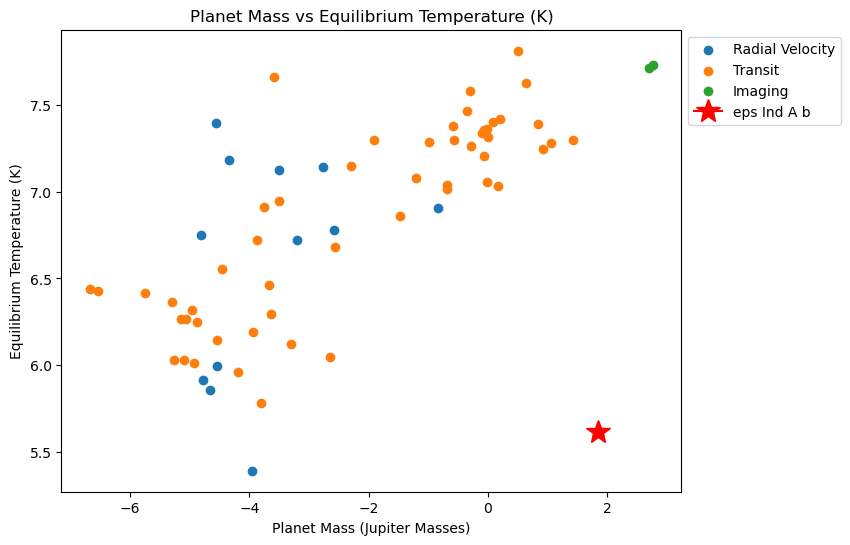

In [127]:
plt.figure(figsize = (8, 6)) 
discovery_method = new2_df["discoverymethod"].unique()
for method in discovery_method:
    mask = new2_df["discoverymethod"] == method
    plt.scatter(np.log(new2_df.loc[mask, "pl_bmassj"]), np.log(new2_df.loc[mask, "pl_eqt"]), label = method)
plt.plot(np.log(6.31), np.log(275.0), color = "red", marker = "*", markersize = 18, label = "eps Ind A b")
plt.title("Planet Mass vs Equilibrium Temperature (K)")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

In [128]:
# A temperate super-Jupiter imaged with JWST in the mid-infrared
# Planets that have been discovered by imaging are relatively young. JWST has taken images of a giant exoplanet that matches claims of a giant planet orbiting a nearby star, but has different orbital properties than claimed. There may be a high metallicity and carbon to oxygen ratio. It's probably the only giant planet in the system.
# Yes
# It was found through imaging despite having such a cold temperature
# Both the equilibrium temperature and mass matches.